# Где дешевле жить? Предсказание цен в Airbnb - учимся генерировать признаки и интерпретировать результаты модели

In [197]:
#YOUR CODE HERE

import kagglehub
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from scipy import stats
from scipy.stats import norm

path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")


print("Path to dataset files:", path)
# Проверяем файлы
print("Доступные файлы:")
for file in os.listdir(path):
    print(f"  • {file}")

# Загружаем основной датасет
dc = pd.read_csv(f'{path}/AB_NYC_2019.csv')
df = dc.copy()
print(df.info())
print(f"\\nРазмер: {df.shape}")
print(df.isnull().sum())
df.head()


Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/new-york-city-airbnb-open-data
Доступные файлы:
  • AB_NYC_2019.csv
  • New_York_City_.png
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   pr

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [198]:
#выкиньте ненужные признаки: id, name, host_id, host_name, last_review
#заполняем 0 пропущенные reviews_per_month

#if 'id' and 'Unnamed: 32' in df.columns:
df_clean = df.drop(['id','name','host_id','host_name','last_review'], axis=1)
df_clean['reviews_per_month'] = df['reviews_per_month'].fillna(0)
print(f"Индексы колонок:\n{df_clean.columns.tolist()}")
df_clean.info()

Индексы колонок:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   neighbourhood                   48895 non-null  object 
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  object 
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               48895 non-null  float64
 

In [199]:
df_clean.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [200]:
data = df_clean.copy()
data.info()
#пропусков нет теперь

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   neighbourhood                   48895 non-null  object 
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  object 
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               48895 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 4.1+ MB


In [201]:
data.price.quantile(0.95)

np.float64(355.0)

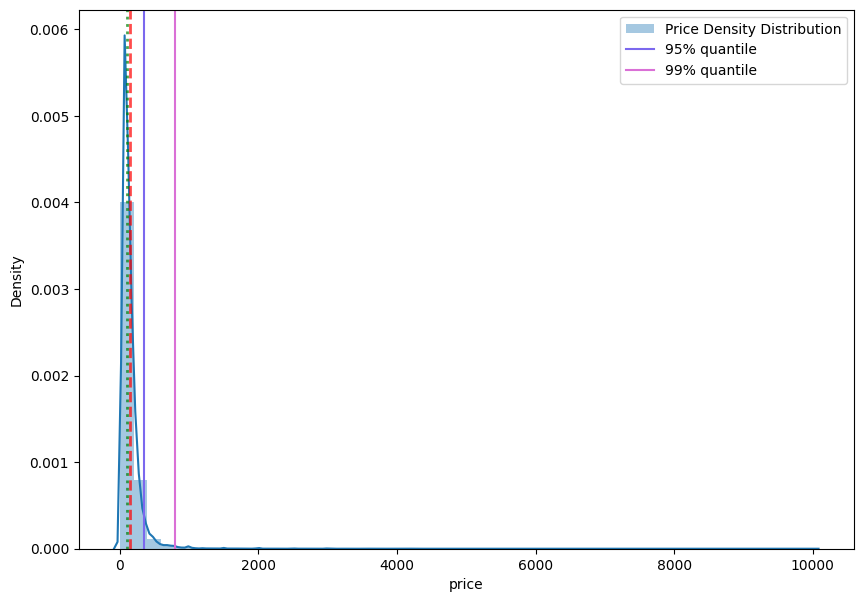

In [202]:
plt.subplots(figsize=(10,7))
sns.distplot(data['price'], label='Price Density Distribution')
plt.axvline(data.price.quantile(0.95), label='95% quantile', c='mediumslateblue')
plt.axvline(data.price.quantile(0.99), label='99% quantile', c='orchid')
plt.axvline(np.mean(data.price), color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.axvline(data.price.median(), color='green', linestyle=':', linewidth=2, alpha=0.7)
plt.legend()
plt.show()

In [203]:
data1 = data[data['room_type'] != 'Entire home/apt']
#даже если выбросить самую дорогую категорию -Entire home/apt- распределение такое же

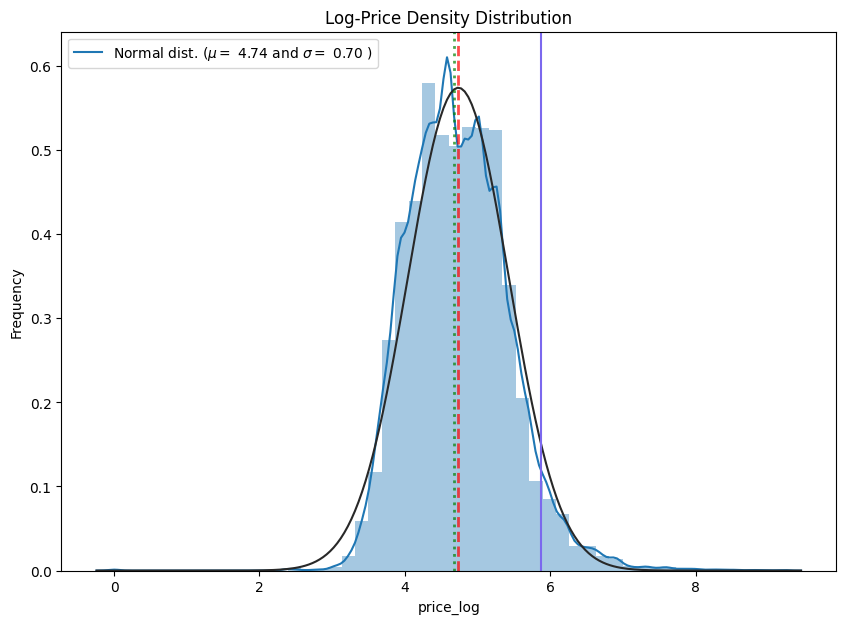

In [204]:
from scipy import stats
from scipy.stats import norm
#применим монотонное преобразование - логарифмируем цел.переменную
data['price_log'] = np.log1p(data['price'])
plt.subplots(figsize=(10,7))
sns.distplot(data.price_log, fit=norm)

# фитим распределение на логарифм от цены
(mu, sigma) = norm.fit(data.price_log)

plt.ylabel('Frequency')
plt.title('Log-Price Density Distribution')

plt.axvline(data.price_log.quantile(0.95), label='95% quantile', c='mediumslateblue')
plt.axvline(np.mean(data.price_log), color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.axvline(data.price_log.median(), color='green', linestyle=':', linewidth=2, alpha=0.7)
plt.legend(['Normal dist. ($\\mu=$ {:.2f} and $\\sigma=$ {:.2f} )'.format(mu, sigma)], loc='best')
plt.show()

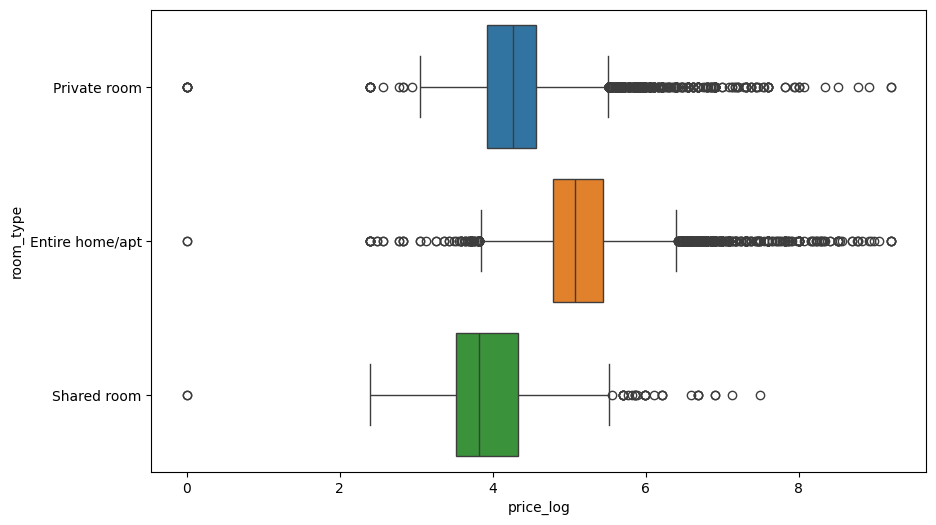

In [205]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data, x='price_log', y='room_type', hue='room_type')
plt.show()

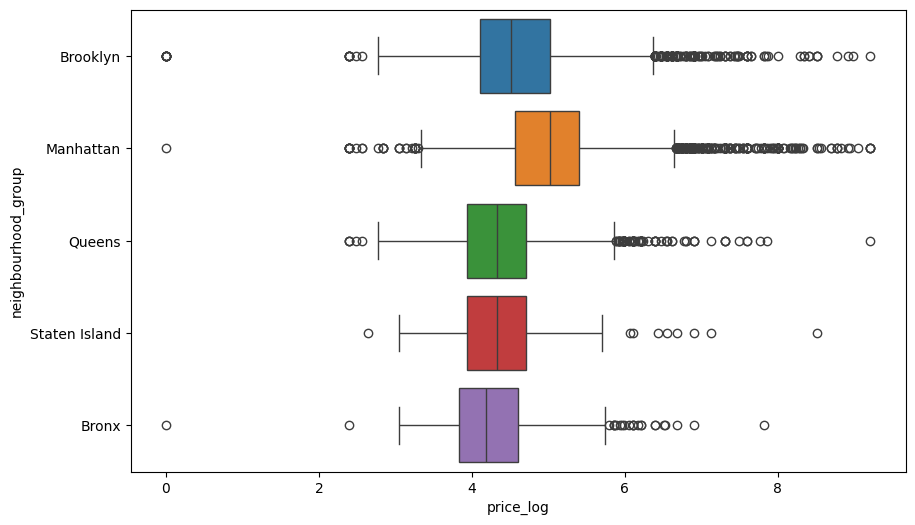

In [206]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data, x='price_log', y='neighbourhood_group', hue='neighbourhood_group')
plt.show()

In [207]:
# перекодируем категориальные исходя из 2х графиков выше
#data['neighbourhood_group'] = data['neighbourhood_group'].map({'Queens':3, 'Staten Island' : 2,'Bronx': 1, 'Manhattan': 5, 'Brooklyn': 4, })
data['room_type_enc'] = data['room_type'].map({'Private room':2, 'Entire home/apt':3, 'Shared room':1})

In [208]:
#помимо выбросов, в этих графиках есть еще одна аномалия
print(f"\n  удаляемых строк с нулевой ценой: {len(df_zero_price)}")

data = data[data['price'] > 0]
data.info()


  удаляемых строк с нулевой ценой: 11
<class 'pandas.core.frame.DataFrame'>
Index: 48884 entries, 0 to 48894
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48884 non-null  object 
 1   neighbourhood                   48884 non-null  object 
 2   latitude                        48884 non-null  float64
 3   longitude                       48884 non-null  float64
 4   room_type                       48884 non-null  object 
 5   price                           48884 non-null  int64  
 6   minimum_nights                  48884 non-null  int64  
 7   number_of_reviews               48884 non-null  int64  
 8   reviews_per_month               48884 non-null  float64
 9   calculated_host_listings_count  48884 non-null  int64  
 10  availability_365                48884 non-null  int64  
 11  price_log                       48884 non-null  float64
 12

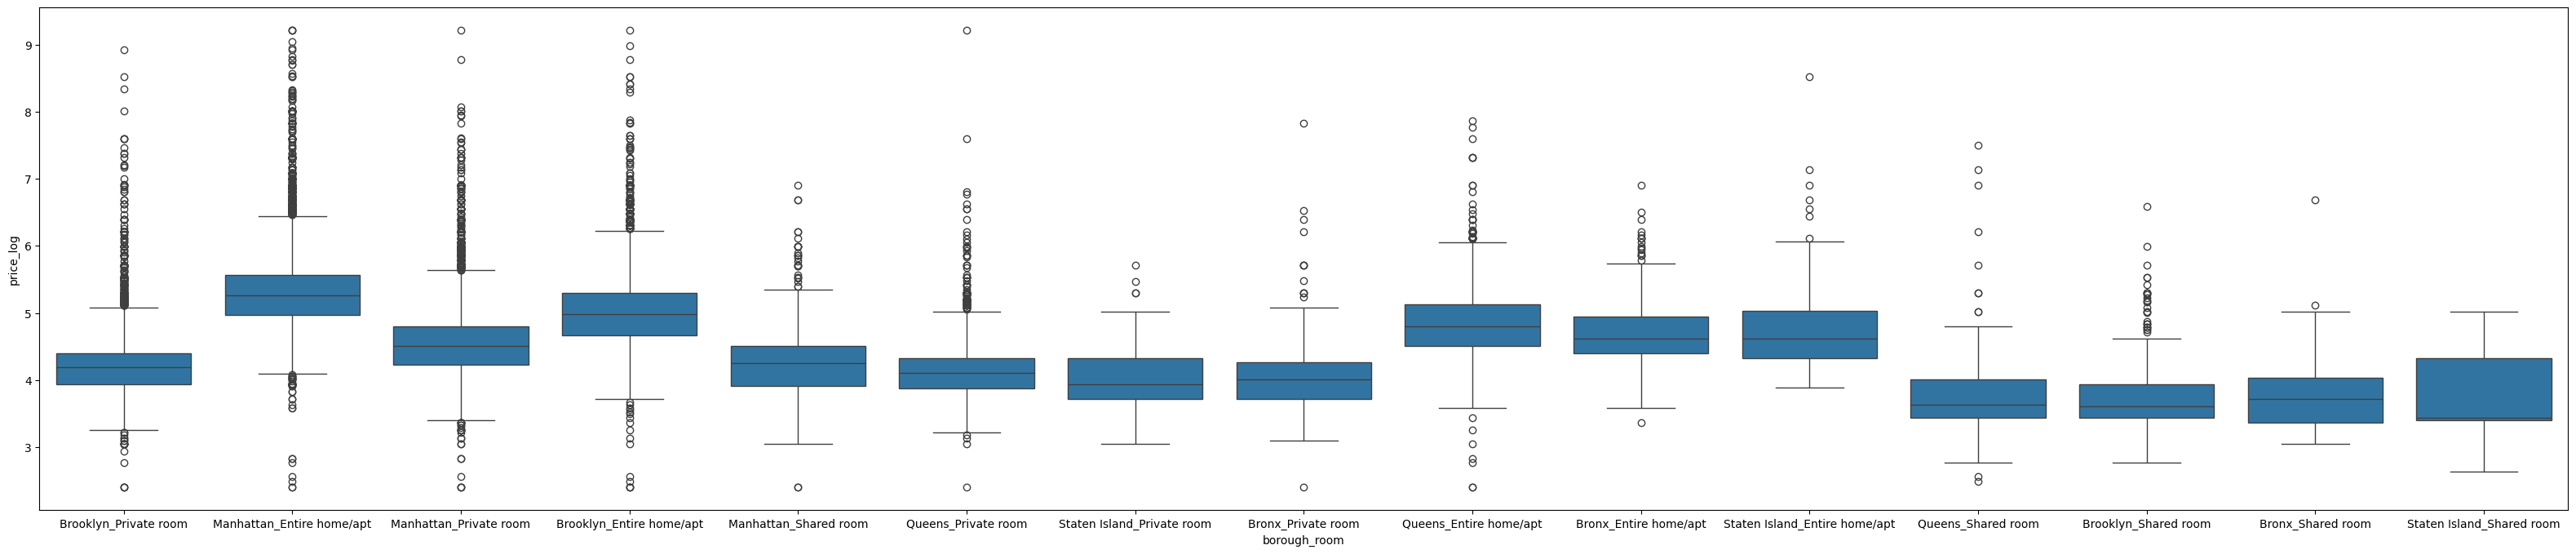

In [209]:
data['borough_room'] = data['neighbourhood_group'] + '_' + data['room_type']
plt.figure(figsize=(40, 8))
sns.boxplot(data=data, x='borough_room', y="price_log")
plt.show()
# нужно проработать выбросы (их ожидаемо много в популярных категориях)


📋 Всего объявлений: 48895
   Уникальных neighbourhood: 221

📈 4. ГРАФИК 3: КРУГОВАЯ ДИАГРАММА (ТОП-10)
----------------------------------------


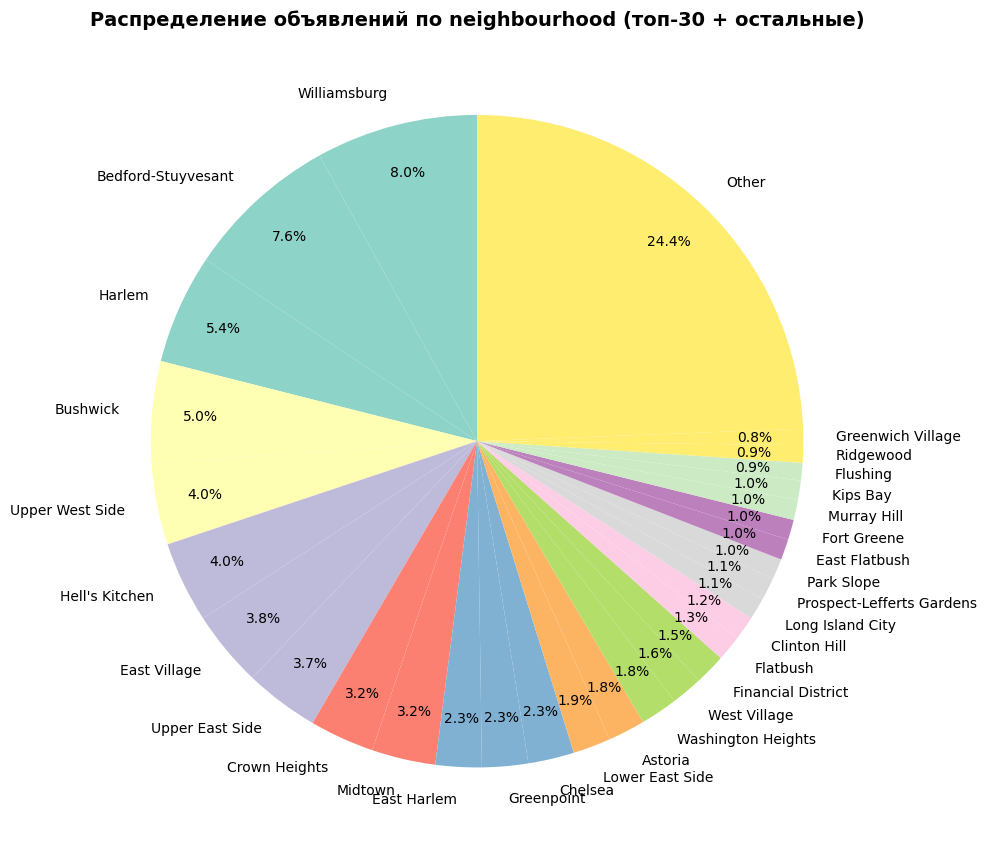


  ОБЩАЯ СТАТИСТИКА:
  • Всего neighbourhood: 221
  • Среднее объявлений на neighbourhood: 221.2
  • Медиана объявлений: 32.0
  • Максимум: 3920 (Williamsburg)
  • Минимум: 1 (Willowbrook)
  
  КОНЦЕНТРАЦИЯ:
  • Топ-10 neighbourhood: 23446 объявлений (48.0%)
  • Топ-30 neighbourhood: 32206 объявлений (75.6%)
  • Топ-50% neighbourhood покрывают: 97.3% данных
  
  "ХВОСТ" РАСПРЕДЕЛЕНИЯ:
  • neighbourhood с < 10 объявлений: 53
  • neighbourhood с < 5 объявлений: 26
  • neighbourhood с 1 объявлением: 6



In [210]:

print(f"\n📋 Всего объявлений: {len(df)}")
print(f"   Уникальных neighbourhood: {df['neighbourhood'].nunique()}")
# PIE CHART (ТОП-30 + OTHER)

print("\n📈 4. ГРАФИК 3: КРУГОВАЯ ДИАГРАММА (ТОП-10)")
print("-" * 40)

top_10 = neighbourhood_counts.head(30)
other_count = neighbourhood_counts[30:].sum()

pie_data = pd.concat([top_10, pd.Series({'Other': other_count})])

plt.figure(figsize=(10, 10))
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(pie_data)))
wedges, texts, autotexts = plt.pie(pie_data.values, labels=pie_data.index,
                                     autopct='%1.1f%%', colors=colors_pie,
                                     startangle=90, pctdistance=0.85)
plt.title('Распределение объявлений по neighbourhood (топ-30 + остальные)',
          fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


#borough_colors = {'Manhattan': '#FF6B6B','Brooklyn': '#4ECDC4','Queens': '#45B7D1','Bronx': '#96CEB4','Staten Island': '#FFEAA7' }

print(f"""
  ОБЩАЯ СТАТИСТИКА:
  • Всего neighbourhood: {len(neighbourhood_counts)}
  • Среднее объявлений на neighbourhood: {neighbourhood_counts.mean():.1f}
  • Медиана объявлений: {neighbourhood_counts.median():.1f}
  • Максимум: {neighbourhood_counts.max()} ({neighbourhood_counts.index[0]})
  • Минимум: {neighbourhood_counts.min()} ({neighbourhood_counts.index[-1]})

  КОНЦЕНТРАЦИЯ:
  • Топ-10 neighbourhood: {neighbourhood_counts.head(10).sum()} объявлений ({neighbourhood_pct.head(10).sum():.1f}%)
  • Топ-30 neighbourhood: {neighbourhood_counts.head(20).sum()} объявлений ({neighbourhood_pct.head(30).sum():.1f}%)
  • Топ-50% neighbourhood покрывают: {neighbourhood_pct.head(len(neighbourhood_counts)//2).sum():.1f}% данных

  "ХВОСТ" РАСПРЕДЕЛЕНИЯ:
  • neighbourhood с < 10 объявлений: {(neighbourhood_counts < 10).sum()}
  • neighbourhood с < 5 объявлений: {(neighbourhood_counts < 5).sum()}
  • neighbourhood с 1 объявлением: {(neighbourhood_counts == 1).sum()}
""")



In [211]:
data.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price_log,room_type_enc,borough_room
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,5.010635,2,Brooklyn_Private room
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,5.420535,3,Manhattan_Entire home/apt
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,5.017280,2,Manhattan_Private room
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,4.499810,3,Brooklyn_Entire home/apt
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,4.394449,3,Manhattan_Entire home/apt


In [212]:
#расстояние до цента Манхеттена
# 'Midtown Manhattan': (40.7549, -73.9840),  # Геометрический центр
# взять евк или манхеттенское расстояние и округлить
from math import radians, sin, cos, sqrt, atan2

CENTER_LAT, CENTER_LON = 40.7549, -73.9840

def haversine_distance(lat1, lon1, lat2, lon2):
       R = 6371
       lat1_rad, lat2_rad = radians(lat1), radians(lat2)
       dlat = radians(lat2 - lat1)
       dlon = radians(lon2 - lon1)
       a = sin(dlat/2)**2 + cos(lat1_rad)*cos(lat2_rad)*sin(dlon/2)**2
       return R * 2 * atan2(sqrt(a), sqrt(1-a))

def euclidean_distance(lat1, lon1, lat2, lon2):
    """
    Приближенное евклидово расстояние (в километрах)
    Быстрее, но менее точно на больших расстояниях
    """
    # 1 градус широты ≈ 111.32 км
    # 1 градус долготы ≈ 111.32 * cos(широта) км
    lat_km = 111.32
    lon_km = 111.32 * cos(radians((lat1 + lat2) / 2))

    dlat_km = (lat2 - lat1) * lat_km
    dlon_km = (lon2 - lon1) * lon_km

    return sqrt(dlat_km**2 + dlon_km**2)
#df0 = data.copy()
data['D_to_manhattan_km'] = data.apply(
       lambda row:    euclidean_distance(row['latitude'], row['longitude'],
                                      CENTER_LAT, CENTER_LON), axis=1
   ).round(2)
data.head()
#попробуем вывести расстояния до каждого из центров районов
#'Queens':4, 'Staten Island' : 5,'Bronx': 1, 'Manhattan': 3, 'Brooklyn': 2,


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price_log,room_type_enc,borough_room,D_to_manhattan_km
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,5.010635,2,Brooklyn_Private room,12.00
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,5.420535,3,Manhattan_Entire home/apt,0.14
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,5.017280,2,Manhattan_Private room,6.99
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,4.499810,3,Brooklyn_Entire home/apt,8.03
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,4.394449,3,Manhattan_Entire home/apt,5.91


In [213]:
group_medians = (data.groupby('neighbourhood_group')['price'].mean()/6).round()
print(group_medians)
data['group_enc'] = data['neighbourhood_group'].map(group_medians)

neighbourhood_group
Bronx            15.0
Brooklyn         21.0
Manhattan        33.0
Queens           17.0
Staten Island    19.0
Name: price, dtype: float64


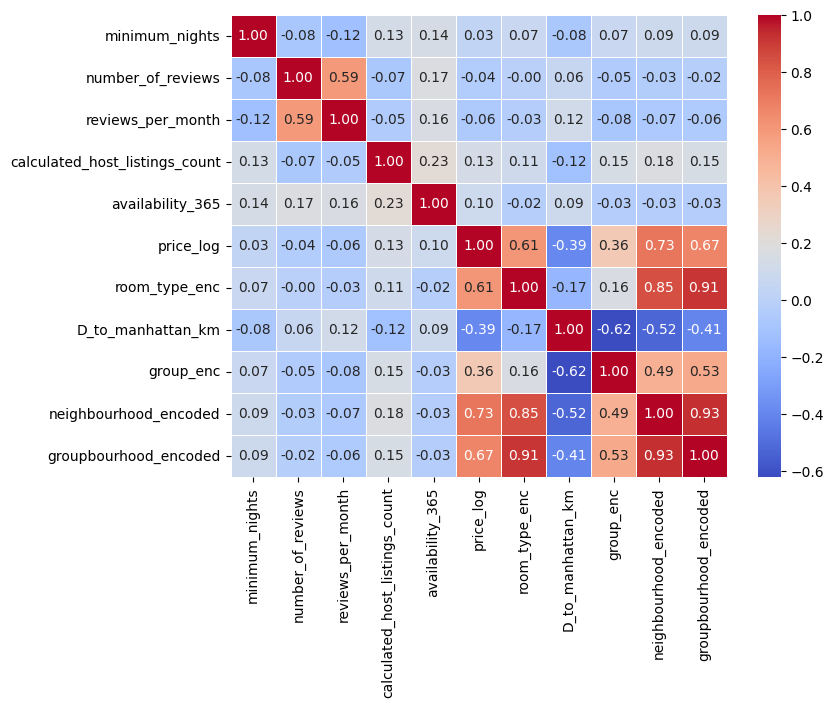

In [214]:

data['borough_room'] = data['neighbourhood_group'] + '_' + data['room_type']
data['neigh_room'] = data['neighbourhood'] + '_' + data['room_type']
neigh_medians = data.groupby('neigh_room')['price_log'].median()
borough_medians = data.groupby('borough_room')['price_log'].median()
#group_medians = (data.groupby('neighbourhood_group')['price'].mean()/6).round()
#print(group_medians)
#data['group_encoded'] = data['neighbourhood_group'].map(group_medians)
data['neighbourhood_encoded'] = data['neigh_room'].map(neigh_medians)
data['groupbourhood_encoded'] = data['borough_room'].map(borough_medians)

#correlation map
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()

# Обычно исключаем:
exclude_for_model = [ 'latitude', 'longitude', 'price']

# Числовые колонки, которые МОЖНО использовать
model_cols = [c for c in numeric_cols if c not in exclude_for_model]
correlation_matrix = data[model_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(data[model_cols].corr(), cmap='coolwarm', annot=True, cbar=True, linewidths=.5, fmt= '.2f')
plt.show()

  Найдено 14 пар с |r| > 0.35



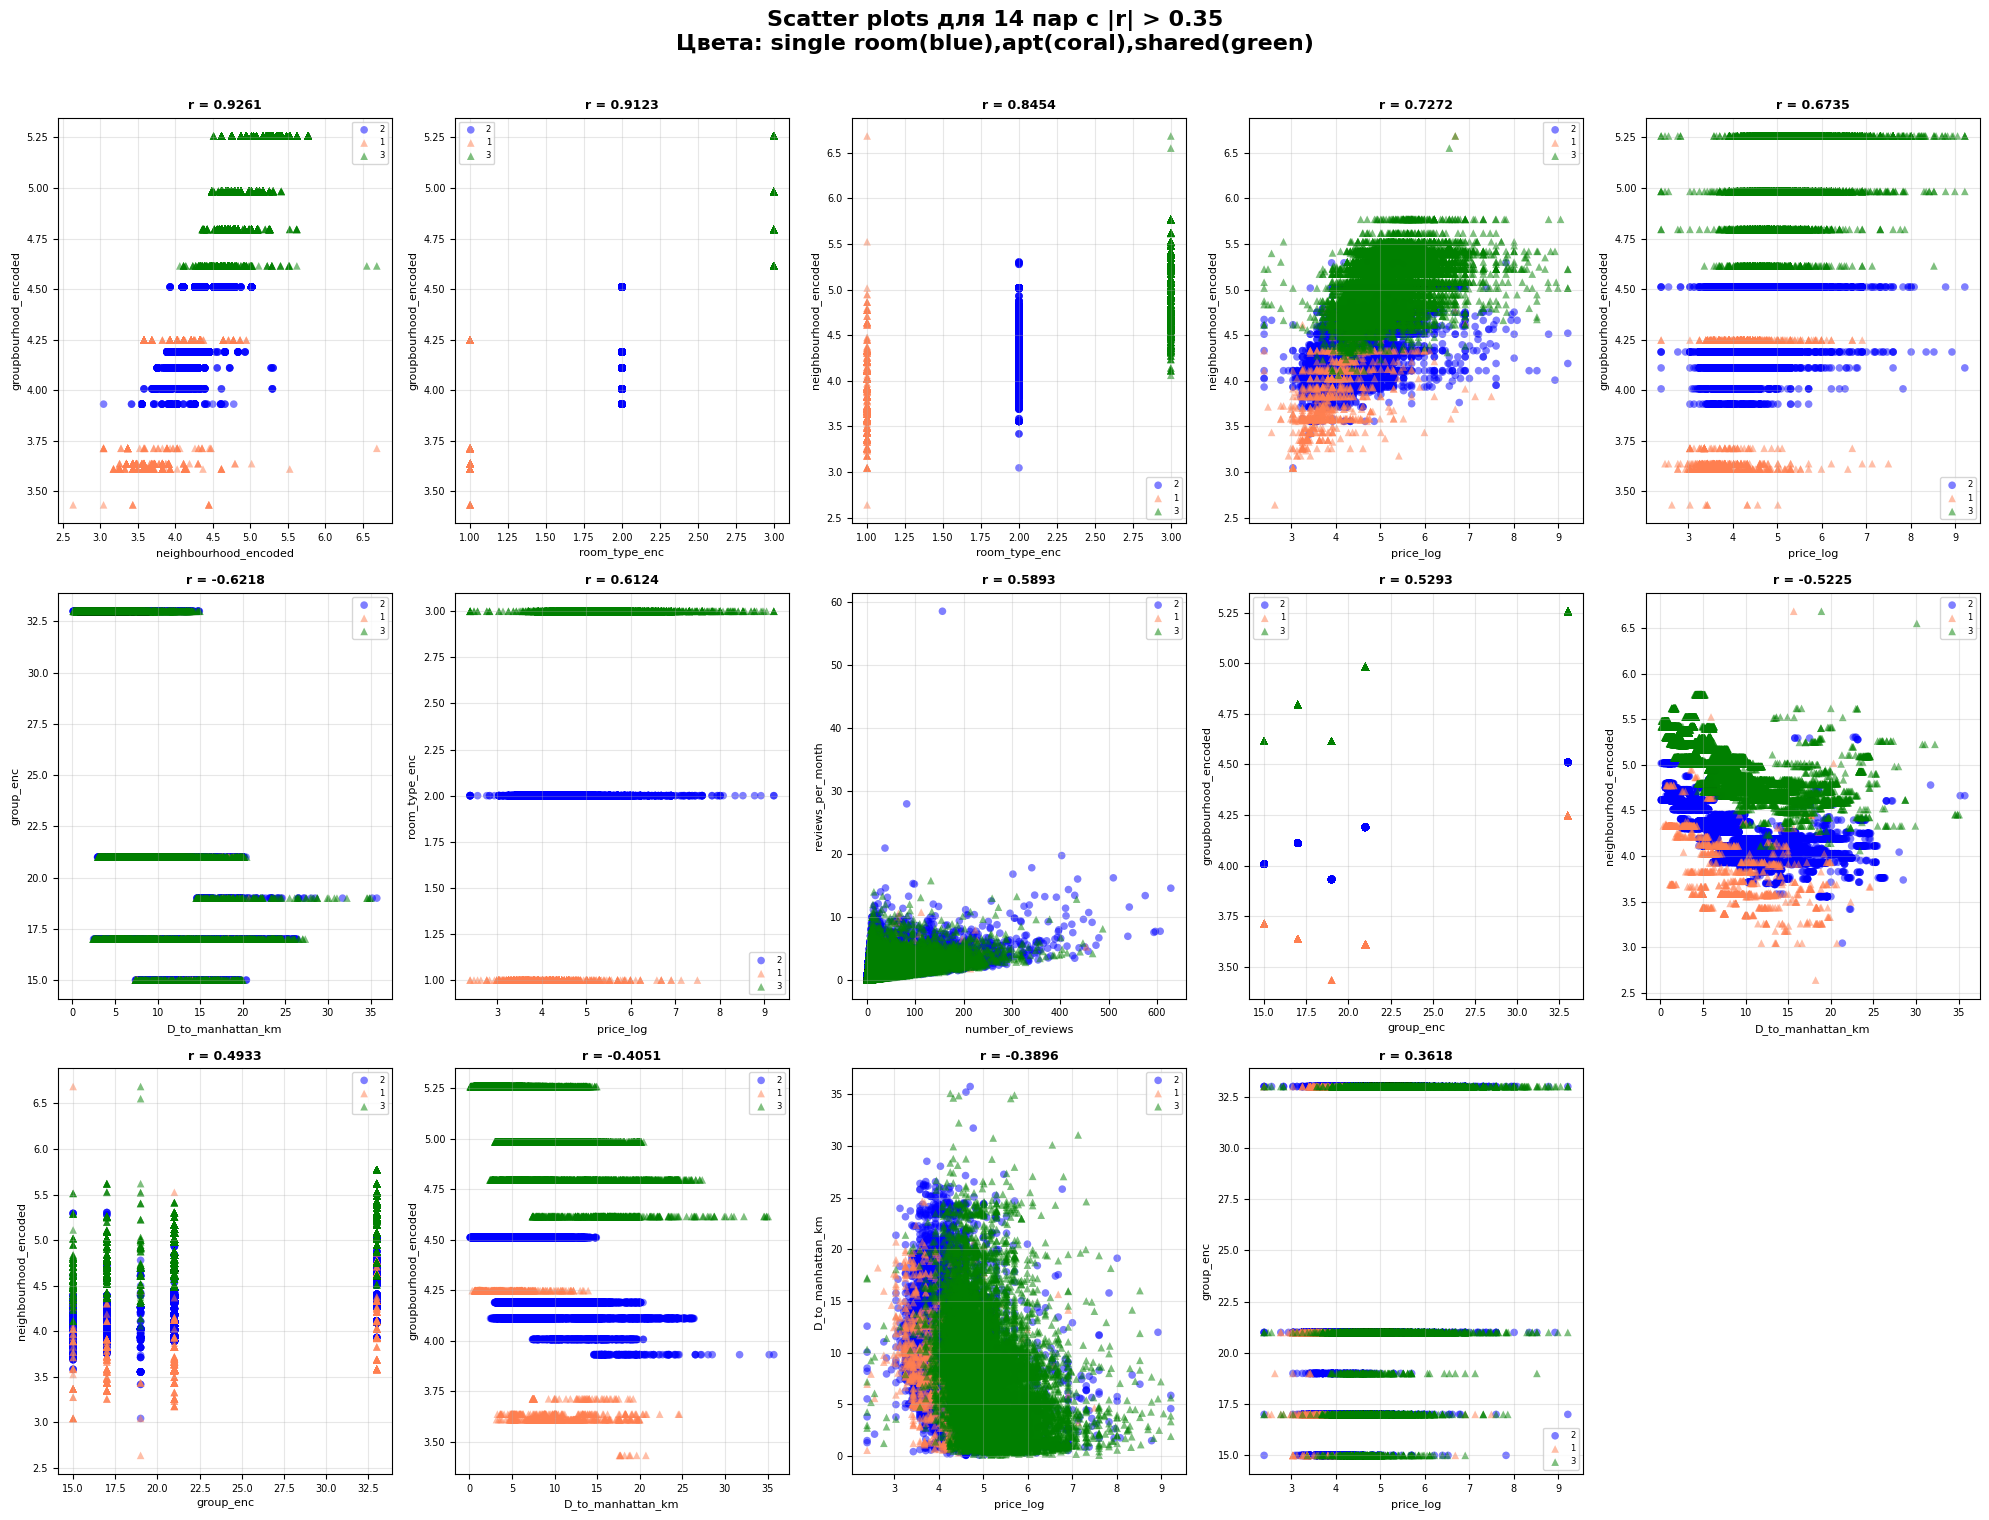

In [215]:
#pairplots

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.35:
            high_corr_pairs.append({
                'feature1': correlation_matrix.columns[i],
                'feature2': correlation_matrix.columns[j],
                'correlation': corr_val
            })

# Сортируем по убыванию |r|
high_corr_pairs_sorted = sorted(high_corr_pairs,
                                key=lambda x: abs(x['correlation']),
                                reverse=True)

print(f"  Найдено {len(high_corr_pairs_sorted)} пар с |r| > 0.35\n")
#print((high_corr_pairs_sorted))
n_pairs = len(high_corr_pairs_sorted)
n_cols = 5
n_rows = (n_pairs + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for idx, pair in enumerate(high_corr_pairs_sorted):
    ax = axes[idx]
    f1, f2, corr = pair['feature1'], pair['feature2'], pair['correlation']

    # Scatter plot с раскраской по диагнозу
    for room_type_enc, color, marker, alpha in [
        (2, 'blue', 'o', 0.5),
        (1, 'coral', '^', 0.5),
        (3, 'green', '^', 0.5)
    ]:
        mask = data['room_type_enc'] == room_type_enc
        ax.scatter(data.loc[mask, f1], data.loc[mask, f2],
                  c=color, marker=marker, alpha=alpha, s=30,
                  edgecolors='none', label=room_type_enc)



    ax.set_xlabel(f1, fontsize=8)
    ax.set_ylabel(f2, fontsize=8)
    ax.set_title(f'r = {corr:.4f}', fontsize=9, fontweight='bold')
    ax.legend(fontsize=6, loc='best')
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=7)
    plt.suptitle(f'Scatter plots для {n_pairs} пар с |r| > 0.35\nЦвета: single room(blue),apt(coral),shared(green)',
                fontsize=16, fontweight='bold', y=1.01)

for idx in range(n_pairs, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [241]:
data.columns.tolist()

['neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365',
 'price_log',
 'room_type_enc',
 'borough_room',
 'D_to_manhattan_km',
 'neigh_room',
 'neighbourhood_encoded',
 'groupbourhood_encoded',
 'nbhd_Brooklyn',
 'nbhd_Manhattan',
 'nbhd_Queens',
 'nbhd_Staten Island',
 'nbhd_17.0',
 'nbhd_19.0',
 'nbhd_21.0',
 'nbhd_33.0',
 'neigh_x_room',
 'sqrt',
 'reviews_interaction']

In [236]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score
import warnings
warnings.filterwarnings('ignore')


# построим модель
#dummies
'''
data = pd.get_dummies(data, columns=['group_enc'], prefix='nbhd', drop_first=True)

dummies = data[[c for c in data.columns if not c.startswith('nbhd_')]]


print(f"\n  ✅ DataFrame БЕЗ 'nbhd_' колонок: {dummies.shape}")
'''

base_features = ['minimum_nights', 'number_of_reviews','availability_365', 'reviews_per_month','D_to_manhattan_km','calculated_host_listings_count','room_type_enc']

y = data['price_log']

# Winsorization (на оригинальной цене)
for col in ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']:
    if col in data.columns:
        data[col] = data[col].clip(data[col].quantile(0.01), data[col].quantile(0.99))

# Обновляем log_price после winsorization
df['log_price'] = np.log1p(df['price'])

results = {}


'''
1. std scaller a=1 enc  group
2. std scaller a = 1 dummies  group
data_ohe = pd.get_dummies(data, columns=['neighbourhood_group'], prefix='nbhd', drop_first=True)
3. rbst scaller a=1 enc group
4. rbst scaller a = 1 room + group
4. rbst scaller a = 1 enc neig + group
5. rbst sqrt neigh enc
'''

In [237]:

def evaluate_with_log(X, y_log, encoding_name, n_features):
    """
    Оценка модели с УЧЕТОМ log-трансформации.

    ВАЖНО:
    - Модель обучается на log_price
    - R² считается в log-шкале
    - RMSE/MAE считаются в ОРИГИНАЛЬНОЙ шкале (через expm1)
    """
    X_train, X_test, y_train_log, y_test_log = train_test_split(
        X, y_log, test_size=0.3, random_state=42
    )

    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    results = {}

    models_to_test = {
        'Linear Regression': LinearRegression(),
        'RidgeCV': RidgeCV(alphas=np.logspace(-3, 3, 20), cv=5, scoring='r2'),
        'LassoCV': LassoCV(cv=5, random_state=42, max_iter=5000, n_alphas=20),
        'ElasticNetCV': ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
                                     cv=5, random_state=42, max_iter=5000, n_alphas=10),
        'Ridge (α=1.0)': Ridge(alpha=1.0),
        'Ridge (α=0.1)': Ridge(alpha=0.1),
    }

    for model_name, model in models_to_test.items():
        model.fit(X_train_scaled, y_train_log)

        # Предсказания В LOG-ШКАЛЕ
        y_pred_log = model.predict(X_test_scaled)

        # ===========================================
        # МЕТРИКИ В LOG-ШКАЛЕ (то, что видит модель)
        # ===========================================
        r2_log = r2_score(y_test_log, y_pred_log)
        rmse_log = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
        mae_log = mean_absolute_error(y_test_log, y_pred_log)

        # ===========================================
        # МЕТРИКИ В ОРИГИНАЛЬНОЙ ШКАЛЕ ($)
        # ===========================================
        y_test_orig = np.expm1(y_test_log)      # Обратно в доллары
        y_pred_orig = np.expm1(y_pred_log)      # Обратно в доллары

        rmse_dollars = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
        mae_dollars = mean_absolute_error(y_test_orig, y_pred_orig)

        # MAPE (Mean Absolute Percentage Error)
        mape = np.mean(np.abs((y_test_orig - y_pred_orig) / y_test_orig)) * 100

        # Кросс-валидация (в log-шкале)
        cv_scores = cross_val_score(model, X_train_scaled, y_train_log, cv=5, scoring='r2')

        # Параметры
        if 'CV' in model_name:
            if hasattr(model, 'alpha_'):
                params = f'α={model.alpha_:.4f}'
                if hasattr(model, 'l1_ratio_'):
                    params += f', l1={model.l1_ratio_:.2f}'
                    n_nonzero = np.sum(model.coef_ != 0)
                    params += f' ({n_nonzero} призн.)'
            else:
                params = 'CV'
        else:
            params = f'α={model.alpha}' if hasattr(model, 'alpha') else 'N/A'

        results[model_name] = {
            # В log-шкале
            'R² (log)': r2_log,
            'RMSE (log)': rmse_log,
            'MAE (log)': mae_log,
            # В оригинальной шкале ($)
            'R² (log)': r2_log,
            'RMSE ($)': rmse_dollars,
            'MAE ($)': mae_dollars,
            'MAPE (%)': mape,
            # Кросс-валидация
            'CV R²': cv_scores.mean(),
            'CV std': cv_scores.std(),
            # Параметры
            'params': params,
            'model': model
        }

    return results, X_test_scaled, y_test_log

In [242]:
# 3. ПРИМЕР ОЦЕНКИ ОДНОГО ПОДХОДА
# ═══════════════════════════════════════════════════════════
print("\n📊 3. ПРИМЕР ОЦЕНКИ (Раздельно: neigh + room)")
print("-" * 40)

extra_features = ['neighbourhood_encoded', 'nbhd_Brooklyn',
 'nbhd_Manhattan',
 'nbhd_Queens',
 'nbhd_Staten Island',]
X = data[base_features + extra_features]
y_log = data['price_log']  # ← ЦЕЛЕВАЯ В LOG-ШКАЛЕ!

results, X_test, y_test_log = evaluate_with_log(X, y_log, 'Раздельно', len(features))

# Выводим результаты
print(f"\n  {'Модель':<20s} {'R² (log)':<10s} {'RMSE ($)':<12s} {'MAE ($)':<10s} {'MAPE':<10s} {'CV R²':<10s} {'Параметры'}")
print(f"  {'-'*95}")
for model_name, metrics in results.items():
    print(f"  {model_name:<20s} {metrics['R² (log)']:<10.4f} ${metrics['RMSE ($)']:<11.2f} "
          f"${metrics['MAE ($)']:<9.2f} {metrics['MAPE (%)']:<9.1f}% "
          f"{metrics['CV R²']:<10.4f} {metrics['params']}")


📊 3. ПРИМЕР ОЦЕНКИ (Раздельно: neigh + room)
----------------------------------------

  Модель               R² (log)   RMSE ($)     MAE ($)    MAPE       CV R²      Параметры
  -----------------------------------------------------------------------------------------------
  Linear Regression    0.5538     $180.09      $57.40     34.0     % 0.5623     N/A
  RidgeCV              0.5538     $180.10      $57.40     34.0     % 0.5623     α=6.1585
  LassoCV              0.5537     $180.33      $57.34     33.9     % 0.5621     α=0.0030
  ElasticNetCV         0.5537     $180.34      $57.34     33.9     % 0.5621     α=0.0034, l1=0.90 (8 призн.)
  Ridge (α=1.0)        0.5538     $180.10      $57.40     34.0     % 0.5623     α=1.0
  Ridge (α=0.1)        0.5538     $180.09      $57.40     34.0     % 0.5623     α=0.1


Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
🏆 ФИНАЛЬНАЯ МОДЕЛЬ ЛИНЕЙНОЙ РЕГРЕССИИ

📋 ШАГ 1: ОЧИСТКА ДАННЫХ
----------------------------------------
  Исходный размер: (48895, 16)
  После очистки: (48884, 16)

🔧 ШАГ 2: WINSORIZATION ВЫБРОСОВ
----------------------------------------
  price                    : выбросов 867 → 0
  minimum_nights           : выбросов 469 → 0
  number_of_reviews        : выбросов 480 → 0
  reviews_per_month        : выбросов 486 → 0
  availability_365         : выбросов 0 → 0

📐 ШАГ 3: LOG-ТРАНСФОРМАЦИЯ ЦЕНЫ
----------------------------------------
  Исходная цена:
    Среднее: $144.03
    Асимметрия: 2.7798
  Log-цена:
    Среднее: 4.7345
    Асимметрия: 0.4100

🔨 ШАГ 4: FEATURE ENGINEERING
----------------------------------------
  Признаков после кодирования: 24

🎯 ШАГ 5: ОТБОР ПРИЗНАКОВ
----------------------------------------
  Признаков: ['minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_h

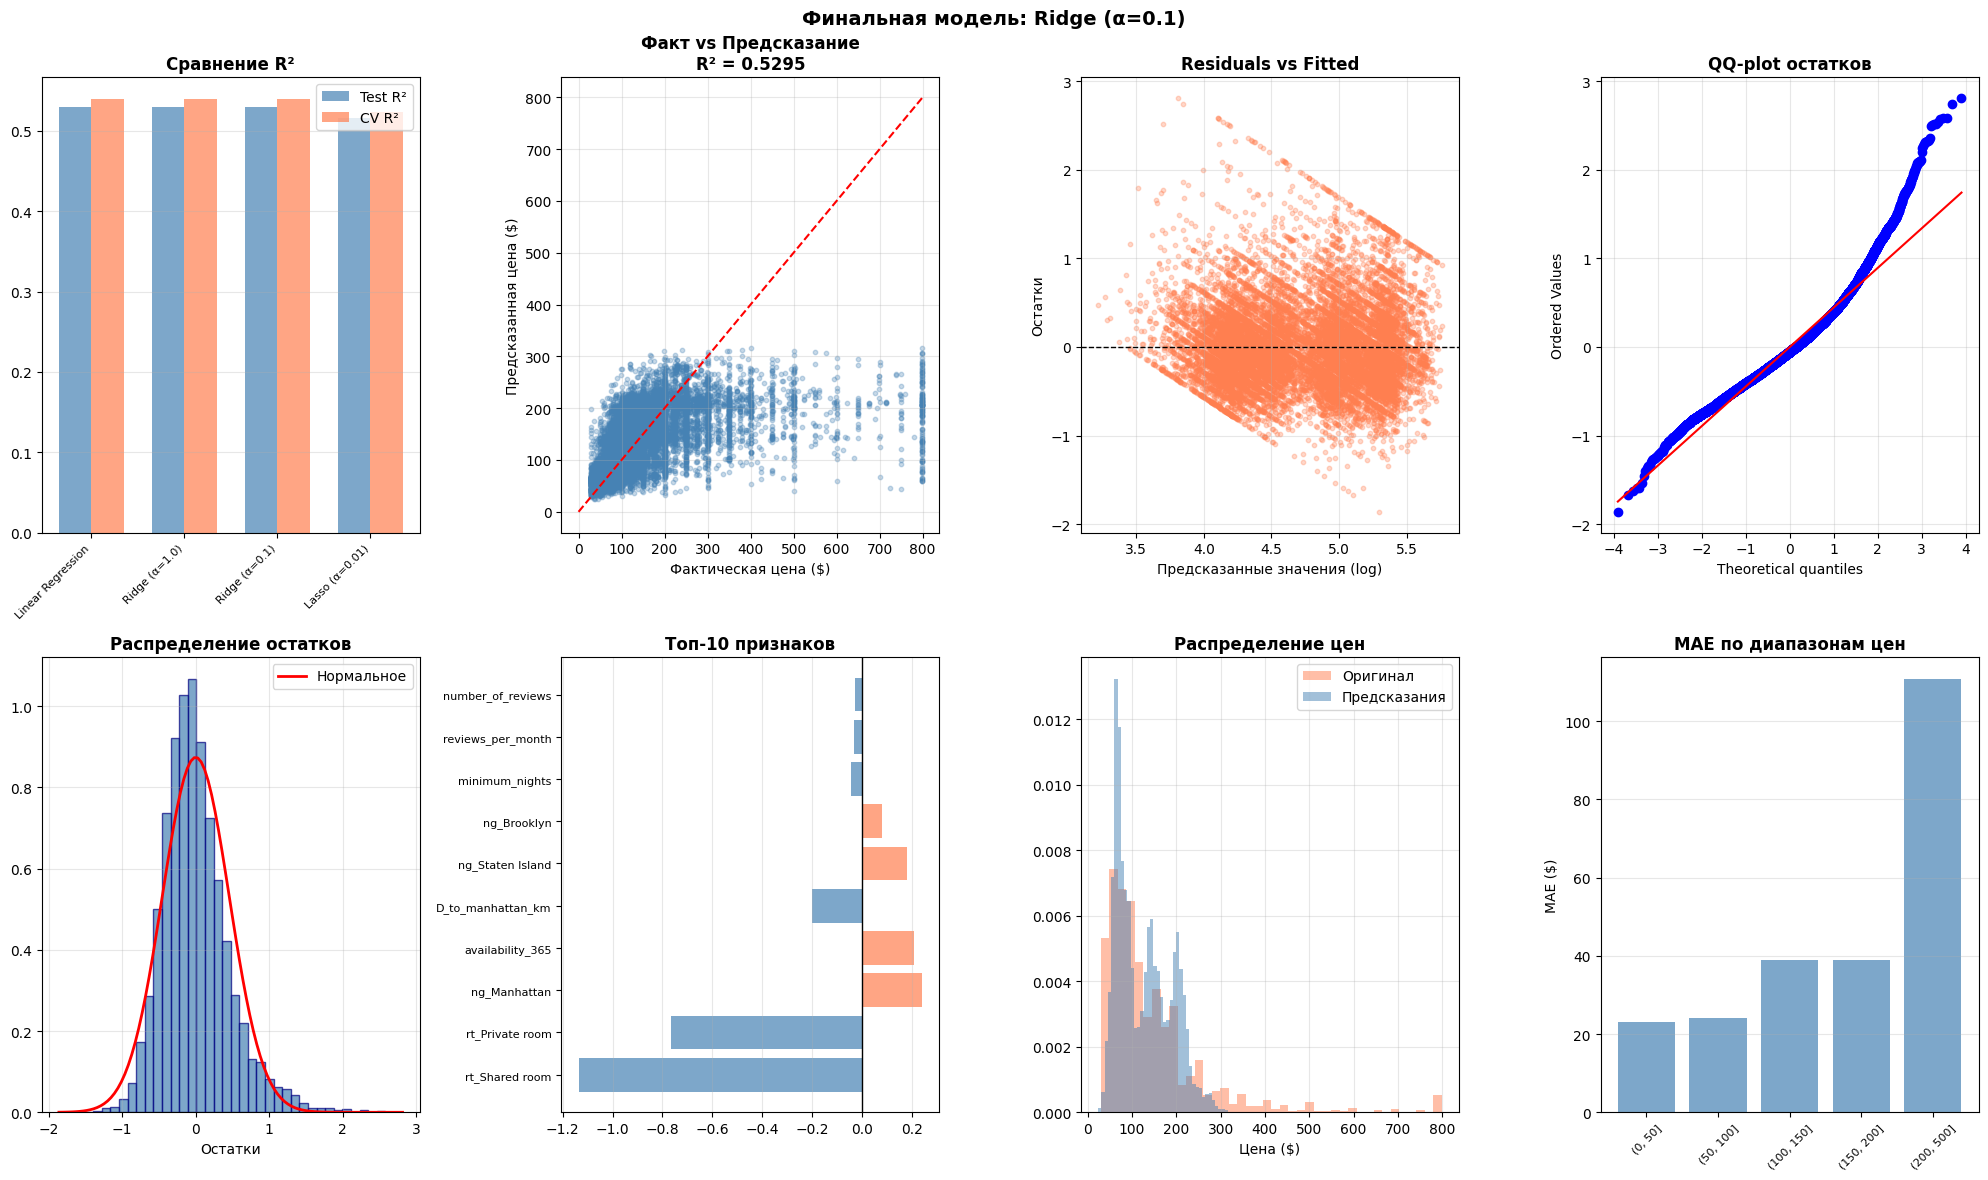


🔮 ПРИМЕРЫ ПРЕДСКАЗАНИЙ
----------------------------------------

      Факт   Предск   Ошибка   Ошибка %
  ----------------------------------------
  $ 195.00 $ 209.66 $ -14.66      -7.5%
  $ 219.00 $ 186.06 $ +32.94     +15.0%
  $ 109.00 $ 106.70 $  +2.30      +2.1%
  $ 100.00 $  77.47 $ +22.53     +22.5%
  $  65.00 $  71.56 $  -6.56     -10.1%
  $  90.00 $  58.18 $ +31.82     +35.4%
  $  50.00 $  58.10 $  -8.10     -16.2%
  $  35.00 $  62.62 $ -27.62     -78.9%
  $  60.00 $  86.52 $ -26.52     -44.2%
  $ 189.00 $ 174.46 $ +14.54      +7.7%

🏆 ИТОГИ

✅ ФИНАЛЬНАЯ МОДЕЛЬ ПОСТРОЕНА!

📊 ХАРАКТЕРИСТИКИ:
   • Модель: Ridge (α=0.1)
   • Признаков: 13
   • Образцов: 48884 (train: 34218, test: 14666)

🔧 ПРИМЕНЕННЫЕ УЛУЧШЕНИЯ:
   1. ✅ Winsorization (1% и 99%)
   2. ✅ Log-трансформация цены
   3. ✅ RobustScaler
   4. ✅ One-Hot Encoding
   5. ✅ Регуляризация (Ridge/Lasso)

📈 РЕЗУЛЬТАТЫ:
   • R²: 0.5295
   • RMSE: $100.62
   • MAE: $52.77
   • CV R²: 0.5398 ± 0.0073

📝 ИНТЕРПРЕТАЦИЯ (топ-3 призна

In [253]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats
from math import radians, sin, cos, sqrt, atan2
import warnings
warnings.filterwarnings('ignore')





path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")
dc = pd.read_csv(f'{path}/AB_NYC_2019.csv')
df = dc.copy()

print("="*60)
print("🏆 ФИНАЛЬНАЯ МОДЕЛЬ ЛИНЕЙНОЙ РЕГРЕССИИ")
print("="*60)

# ═══════════════════════════════════════════════════════════
# ШАГ 1: ОЧИСТКА И ПОДГОТОВКА ДАННЫХ
# ═══════════════════════════════════════════════════════════
print("\n📋 ШАГ 1: ОЧИСТКА ДАННЫХ")
print("-" * 40)

print(f"  Исходный размер: {df.shape}")

# Удаляем строки с пропущенной ценой
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
# Удаляем нулевые цены (бесплатно = ошибка данных)
df = df[df['price'] > 0]
#data = data[data['price'] > 0]
print(f"  После очистки: {df.shape}")

# ═══════════════════════════════════════════════════════════
# ШАГ 2: WINSORIZATION ВЫБРОСОВ
# ═══════════════════════════════════════════════════════════
print("\n🔧 ШАГ 2: WINSORIZATION ВЫБРОСОВ")
print("-" * 40)

# Функция для winsorization
def winsorize_series(series, lower_percentile=0.01, upper_percentile=0.99):
    lower = series.quantile(lower_percentile)
    upper = series.quantile(upper_percentile)
    return series.clip(lower, upper)

# Применяем к числовым признакам
numeric_features = ['price', 'minimum_nights', 'number_of_reviews',
                    'reviews_per_month', 'availability_365']

for col in numeric_features:
    if col in df.columns:
        before_outliers = ((df[col] > df[col].quantile(0.99)) |
                          (df[col] < df[col].quantile(0.01))).sum()
        df[col] = winsorize_series(df[col])
        after_outliers = ((df[col] > df[col].quantile(0.99)) |
                         (df[col] < df[col].quantile(0.01))).sum()
        print(f"  {col:25s}: выбросов {before_outliers} → {after_outliers}")

# ═══════════════════════════════════════════════════════════
# ШАГ 3: LOG-ТРАНСФОРМАЦИЯ ЦЕНЫ
# ═══════════════════════════════════════════════════════════
print("\n📐 ШАГ 3: LOG-ТРАНСФОРМАЦИЯ ЦЕНЫ")
print("-" * 40)

# Сохраняем оригинальную цену
df['price_original'] = df['price']

# Log-трансформация
df['price_log'] = np.log1p(df['price'])

print(f"  Исходная цена:")
print(f"    Среднее: ${df['price_original'].mean():.2f}")
print(f"    Асимметрия: {stats.skew(df['price_original']):.4f}")
print(f"  Log-цена:")
print(f"    Среднее: {df['price_log'].mean():.4f}")
print(f"    Асимметрия: {stats.skew(df['price_log']):.4f}")

# ═══════════════════════════════════════════════════════════
# ШАГ 4: FEATURE ENGINEERING
# ═══════════════════════════════════════════════════════════
print("\n🔨 ШАГ 4: FEATURE ENGINEERING")
print("-" * 40)

# One-Hot Encoding для категориальных признаков
df_encoded = pd.get_dummies(df, columns=['neighbourhood_group', 'room_type'],
                            prefix=['ng', 'rt'], drop_first=True)

# Дополнительные признаки
if 'reviews_per_month' in df.columns and 'number_of_reviews' in df.columns:
    df_encoded['reviews_interaction'] = df_encoded['reviews_per_month'] * df_encoded['number_of_reviews']
#евкл расстояни
def euclidean_distance(lat1, lon1, lat2, lon2):
    """
    Приближенное евклидово расстояние (в километрах)
    Быстрее, но менее точно на больших расстояниях
    """
    # 1 градус широты ≈ 111.32 км
    # 1 градус долготы ≈ 111.32 * cos(широта) км
    lat_km = 111.32
    lon_km = 111.32 * cos(radians((lat1 + lat2) / 2))

    dlat_km = (lat2 - lat1) * lat_km
    dlon_km = (lon2 - lon1) * lon_km

    return sqrt(dlat_km**2 + dlon_km**2)
#df0 = data.copy()
df_encoded['D_to_manhattan_km'] = df_encoded.apply(
       lambda row:    euclidean_distance(row['latitude'], row['longitude'],
                                      CENTER_LAT, CENTER_LON), axis=1)

print(f"  Признаков после кодирования: {df_encoded.shape[1]}")

# ═══════════════════════════════════════════════════════════
# ШАГ 5: ОТБОР ПРИЗНАКОВ
# ═══════════════════════════════════════════════════════════
print("\n🎯 ШАГ 5: ОТБОР ПРИЗНАКОВ")
print("-" * 40)

# Определяем признаки и целевую переменную
exclude_cols = ['neighbourhood','price', 'price_original', 'price_log', 'id', 'name',
                'host_name', 'host_id', 'last_review', 'latitude', 'longitude']

feature_cols = [c for c in df_encoded.columns if c not in exclude_cols]

# Убираем колонки с одним уникальным значением
feature_cols = [c for c in feature_cols if df_encoded[c].nunique() > 1]
print(f"  Признаков: {feature_cols}")
print(f"  Отобрано признаков: {len(feature_cols)}")
print(f"  Целевая переменная: price_log")

X = df_encoded[feature_cols]
y = df_encoded['price_log']

print(X.columns.to_list())
# ═══════════════════════════════════════════════════════════
# ШАГ 6: РАЗДЕЛЕНИЕ И МАСШТАБИРОВАНИЕ
# ═══════════════════════════════════════════════════════════
print("\n✂️ ШАГ 6: РАЗДЕЛЕНИЕ И МАСШТАБИРОВАНИЕ")
print("-" * 40)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# RobustScaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"  Train: {X_train_scaled.shape}")
print(f"  Test:  {X_test_scaled.shape}")
print(f"  Scaler: RobustScaler")

# ═══════════════════════════════════════════════════════════
# ШАГ 7: ОБУЧЕНИЕ МОДЕЛЕЙ
# ═══════════════════════════════════════════════════════════
print("\n🤖 ШАГ 7: ОБУЧЕНИЕ МОДЕЛЕЙ")
print("-" * 40)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=1.0)': Ridge(alpha=1.0),
    'Ridge (α=0.1)': Ridge(alpha=0.1),
    'Lasso (α=0.01)': Lasso(alpha=0.01, max_iter=5000)
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

    # Метрики в log-шкале
    r2_log = r2_score(y_test, y_pred)
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred))

    # Метрики в оригинальной шкале (обратное преобразование)
    y_pred_orig = np.expm1(y_pred)
    y_test_orig = np.expm1(y_test)
    rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
    mae_orig = mean_absolute_error(y_test_orig, y_pred_orig)

    # Кросс-валидация
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')

    results[name] = {
        'R² (log)': r2_log,
        'RMSE (log)': rmse_log,
        'RMSE ($)': rmse_orig,
        'MAE ($)': mae_orig,
        'CV R²': cv_scores.mean(),
        'CV std': cv_scores.std()
    }

    print(f"  {name}:")
    print(f"    R² = {r2_log:.4f} | RMSE = ${rmse_orig:.2f} | MAE = ${mae_orig:.2f} | CV R² = {cv_scores.mean():.4f}")

# Выбираем лучшую модель
best_model_name = max(results, key=lambda x: results[x]['CV R²'])
best_r2 = results[best_model_name]['R² (log)']
best_rmse = results[best_model_name]['RMSE ($)']

print(f"\n  🏆 Лучшая модель: {best_model_name}")
print(f"     R² = {best_r2:.4f}")
print(f"     RMSE = ${best_rmse:.2f}")

# ═══════════════════════════════════════════════════════════
# ШАГ 8: АНАЛИЗ ЛУЧШЕЙ МОДЕЛИ
# ═══════════════════════════════════════════════════════════
print("\n📊 ШАГ 8: АНАЛИЗ ЛУЧШЕЙ МОДЕЛИ")
print("-" * 40)

best_model = models[best_model_name]
best_model.fit(X_train_scaled, y_train)
y_pred_best = predictions[best_model_name]

# Важность признаков
if hasattr(best_model, 'coef_'):
    coef_df = pd.DataFrame({
        'Признак': X.columns,
        'Коэффициент': best_model.coef_
    })
    coef_df['abs_coef'] = abs(coef_df['Коэффициент'])
    coef_df = coef_df.sort_values('abs_coef', ascending=False)

    print(f"\n  Топ-15 важных признаков:")
    print(f"  {'Признак':<30s} {'Коэффициент':>12s} {'Влияние'}")
    print(f"  {'-'*55}")
    for _, row in coef_df.head(15).iterrows():
        direction = '📈 +' if row['Коэффициент'] > 0 else '📉 -'
        print(f"  {row['Признак']:<30s} {row['Коэффициент']:12.6f} {direction}")

# Интерпретация коэффициентов
print(f"\n  📝 Интерпретация (в log-шкале):")
for _, row in coef_df.head(5).iterrows():
    pct_change = (np.exp(row['Коэффициент']) - 1) * 100
    print(f"    {row['Признак']}: изменение на +1 → цена меняется на {pct_change:+.2f}%")

# ═══════════════════════════════════════════════════════════
# ШАГ 9: ДИАГНОСТИКА ОСТАТКОВ
# ═══════════════════════════════════════════════════════════
print("\n🔍 ШАГ 9: ДИАГНОСТИКА ОСТАТКОВ")
print("-" * 40)

residuals = y_test - y_pred_best

print(f"  Среднее остатков: {residuals.mean():.6f}")
print(f"  Стд остатков: {residuals.std():.4f}")
print(f"  Асимметрия: {stats.skew(residuals):.4f}")
print(f"  Эксцесс: {stats.kurtosis(residuals):.4f}")

# Тесты
from scipy.stats import shapiro, jarque_bera

# Durbin-Watson (автокорреляция)
dw_stat = np.sum(np.diff(residuals)**2) / np.sum(residuals**2)
print(f"  Durbin-Watson: {dw_stat:.4f} (≈2 = нет автокорреляции)")

# ═══════════════════════════════════════════════════════════
# ШАГ 10: ВИЗУАЛИЗАЦИЯ
# ═══════════════════════════════════════════════════════════
print("\n📈 ШАГ 10: ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")

fig, axes = plt.subplots(2, 4, figsize=(20, 12))

# 1. Сравнение R² моделей
model_names = list(results.keys())
r2_values = [results[m]['R² (log)'] for m in model_names]
cv_r2 = [results[m]['CV R²'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35
axes[0, 0].bar(x - width/2, r2_values, width, label='Test R²', color='steelblue', alpha=0.7)
axes[0, 0].bar(x + width/2, cv_r2, width, label='CV R²', color='coral', alpha=0.7)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
axes[0, 0].set_title('Сравнение R²', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Факт vs Предсказание
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_best)
axes[0, 1].scatter(y_test_orig, y_pred_orig, alpha=0.3, s=10, c='steelblue')
axes[0, 1].plot([0, y_test_orig.max()], [0, y_test_orig.max()], 'r--', linewidth=1.5)
axes[0, 1].set_xlabel('Фактическая цена ($)')
axes[0, 1].set_ylabel('Предсказанная цена ($)')
axes[0, 1].set_title(f'Факт vs Предсказание\nR² = {best_r2:.4f}', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Остатки vs Предсказания
axes[0, 2].scatter(y_pred_best, residuals, alpha=0.3, s=10, c='coral')
axes[0, 2].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0, 2].set_xlabel('Предсказанные значения (log)')
axes[0, 2].set_ylabel('Остатки')
axes[0, 2].set_title('Residuals vs Fitted', fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

# 4. QQ-plot остатков
stats.probplot(residuals, dist="norm", plot=axes[0, 3])
axes[0, 3].set_title('QQ-plot остатков', fontweight='bold')
axes[0, 3].grid(True, alpha=0.3)

# 5. Распределение остатков
axes[1, 0].hist(residuals, bins=40, density=True, alpha=0.7, color='steelblue', edgecolor='navy')
x_range = np.linspace(residuals.min(), residuals.max(), 100)
axes[1, 0].plot(x_range, stats.norm.pdf(x_range, 0, residuals.std()),
               'r-', linewidth=2, label='Нормальное')
axes[1, 0].set_title('Распределение остатков', fontweight='bold')
axes[1, 0].set_xlabel('Остатки')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 6. Важность признаков (топ-10)
top10 = coef_df.head(10)
colors_bar = ['coral' if x > 0 else 'steelblue' for x in top10['Коэффициент']]
axes[1, 1].barh(range(len(top10)), top10['Коэффициент'], color=colors_bar, alpha=0.7)
axes[1, 1].set_yticks(range(len(top10)))
axes[1, 1].set_yticklabels(top10['Признак'], fontsize=8)
axes[1, 1].set_title('Топ-10 признаков', fontweight='bold')
axes[1, 1].axvline(0, color='black', linewidth=1)
axes[1, 1].grid(True, alpha=0.3, axis='x')

# 7. Сравнение распределений цен
axes[1, 2].hist(df['price_original'], bins=40, alpha=0.5, label='Оригинал',
                color='coral', density=True)
axes[1, 2].hist(np.expm1(y_pred_best), bins=40, alpha=0.5, label='Предсказания',
                color='steelblue', density=True)
axes[1, 2].set_title('Распределение цен', fontweight='bold')
axes[1, 2].set_xlabel('Цена ($)')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

# 8. Ошибки по диапазонам цен
price_bins = pd.cut(y_test_orig, bins=[0, 50, 100, 150, 200, 500])
errors_by_bin = pd.DataFrame({
    'Цена': y_test_orig,
    'Ошибка': abs(y_test_orig - y_pred_orig),
    'Диапазон': price_bins
}).groupby('Диапазон')['Ошибка'].mean()

axes[1, 3].bar(range(len(errors_by_bin)), errors_by_bin.values,
               color='steelblue', alpha=0.7)
axes[1, 3].set_xticks(range(len(errors_by_bin)))
axes[1, 3].set_xticklabels(errors_by_bin.index, rotation=45, fontsize=8)
axes[1, 3].set_title('MAE по диапазонам цен', fontweight='bold')
axes[1, 3].set_ylabel('MAE ($)')
axes[1, 3].grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Финальная модель: {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════
# 11. ПРИМЕРЫ ПРЕДСКАЗАНИЙ
# ═══════════════════════════════════════════════════════════
print("\n🔮 ПРИМЕРЫ ПРЕДСКАЗАНИЙ")
print("-" * 40)

sample_indices = np.random.choice(len(y_test), 10, replace=False)
print(f"\n  {'Факт':>8s} {'Предск':>8s} {'Ошибка':>8s} {'Ошибка %':>10s}")
print(f"  {'-'*40}")

for idx in sample_indices:
    fact = y_test_orig.iloc[idx]
    pred = y_pred_orig[idx]
    error = fact - pred
    error_pct = (error / fact) * 100
    print(f"  ${fact:7.2f} ${pred:7.2f} ${error:+7.2f} {error_pct:+9.1f}%")

# ═══════════════════════════════════════════════════════════
# 12. ИТОГИ
# ═══════════════════════════════════════════════════════════
print("\n" + "="*60)
print("🏆 ИТОГИ")
print("="*60)

print(f"""
✅ ФИНАЛЬНАЯ МОДЕЛЬ ПОСТРОЕНА!

📊 ХАРАКТЕРИСТИКИ:
   • Модель: {best_model_name}
   • Признаков: {X.shape[1]}
   • Образцов: {len(X)} (train: {len(X_train)}, test: {len(X_test)})

🔧 ПРИМЕНЕННЫЕ УЛУЧШЕНИЯ:
   1. ✅ Winsorization (1% и 99%)
   2. ✅ Log-трансформация цены
   3. ✅ RobustScaler
   4. ✅ One-Hot Encoding
   5. ✅ Регуляризация (Ridge/Lasso)

📈 РЕЗУЛЬТАТЫ:
   • R²: {best_r2:.4f}
   • RMSE: ${best_rmse:.2f}
   • MAE: ${results[best_model_name]['MAE ($)']:.2f}
   • CV R²: {results[best_model_name]['CV R²']:.4f} ± {results[best_model_name]['CV std']:.4f}

📝 ИНТЕРПРЕТАЦИЯ (топ-3 признака):
""")

for _, row in coef_df.head(3).iterrows():
    pct_change = (np.exp(row['Коэффициент']) - 1) * 100
    print(f"   • {row['Признак']}: +1 ед. → цена меняется на {pct_change:+.2f}%")

print(f"""
💡 МОДЕЛЬ ГОТОВА К ИСПОЛЬЗОВАНИЮ!

   # Предсказание цены для новых данных:
   X_new_scaled = scaler.transform(X_new)
   y_pred_log = model.predict(X_new_scaled)
   y_pred_price = np.expm1(y_pred_log)
""")

print("="*60)
print("✅ ГОТОВО!")
print("="*60)